In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("California_Houses.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [ ]:
#separating features and target variable

x = df.drop("Median_House_Value", axis=1)
y = df["Median_House_Value"]

In [ ]:
from sklearn.model_selection import train_test_split

#spliiting the data into training, testing, and validation sets

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=42)
x_test,x_val,y_test,y_val = train_test_split(x_test,y_test, test_size=0.5, random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#scaling the features using MIN-MAX to insure all features contribute equally to the distance calculations
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)
print(x_train.shape[1])


13


### helper plot function

In [ ]:
def plot_accuracies(ranges,accuracies,label,best_idx):
    best_alpha=ranges[best_idx]
    best_error=accuracies[best_idx]
    alphas = np.array(ranges)
    errors = np.array(accuracies)
    plt.figure(figsize=(30,15))
    plt.plot(alphas, errors, marker='o')
    plt.xlabel('Alpha Values',fontsize=17)
    plt.ylabel(label,fontsize=17)
    plt.axvline(best_alpha, linestyle='--', linewidth=1.5, zorder=3, label=f'Best α = {best_alpha:.3g}')
    plt.axhline(best_error,linestyle='--',linewidth=1.5,zorder=3,label=f'Best {label} = {best_error:.5g}')
    plt.scatter([best_alpha], [best_error], s=120, edgecolors='k', zorder=5)
    plt.legend(fontsize=17)
    plt.show()

## Linear Regression from sklearn

In [6]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


reg = LinearRegression()
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 4907211997.374778
Mean Absolute Error: 50790.060271050956


## Linear Regression Direct soluation Implemented class

In [ ]:
class LinearRegressionDirectManual:
    def fit(self,x_train,y_train):
        x=x_train
        # Adding bias term to the input features (a column of ones)
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        
        y=y_train
        # Calculating weights using the Normal Equation: weights = (X^T * X)^(-1) * X^T * y
        firstTerm=np.linalg.inv(x.T @ x) 
        secondTerm=x.T @ y
        self.weights=firstTerm @ secondTerm
        
    def predict_Direct(self,x_test):
        x=x_test
        # Adding bias term to the input features (a column of ones)
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        return x @ self.weights
    

### Trying to predict using direct soluation

In [8]:

reg = LinearRegressionDirectManual()
reg.fit(x_train,y_train)
y_pred = reg.predict_Direct(x_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 4907211997.375058
Mean Absolute Error: 50790.060271045724


## Linear Regression Gradient Descent Implemented class

In [ ]:
class LinearRegressionGradientManual:
    def __init__(self,learning_step=.01,numOfIterations=100000,tolerance=1e-6):
        self.learning_step=learning_step
        self.numOfIterations=numOfIterations
        self.tolerance=tolerance
        
    def fit(self,x_train,y_train):
        x=x_train
        y=y_train
        
        numOfFeatures=x.shape[1]
        numOfSamples=x.shape[0]
        
        #adding bias term to the input features (a column of ones)
        ones=np.ones((numOfSamples,1))
        x=np.hstack([ones,x])
        #setting random seed to get the same results every run
        np.random.seed(42)
        
        #initialize random weights
        self.weights=np.random.randn(numOfFeatures+1)
        prev_cost=float('inf')
        
        #Gradient Descent Algorithm
        for i in range (self.numOfIterations):
            gradient_vector=1/numOfSamples * x.T @ (x @ self.weights - y)
            self.weights=self.weights - self.learning_step * gradient_vector
            current_cost=self._calculateCost(x,y,self.weights)
            if(abs(current_cost-prev_cost)<self.tolerance):
                break
            prev_cost=current_cost   
            
    def _calculateCost(self, x, y, weights):
        y_pred = x @ weights
        cost = np.mean((y_pred - y) ** 2)
        return cost       

        
    def predict_Gradient(self,x_test):
    
        x=x_test
        # Adding bias term to the input features (a column of ones)
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        return x @ self.weights
    

### Finding the best learning step

In [ ]:
learning_step_cand=[.0001, .001, .01 , .1]
best_mse = float('inf')
best_learning_step = None

for learningStep in learning_step_cand:
    reg = LinearRegressionGradientManual(learning_step=learningStep)
    reg.fit(x_train,y_train)
    y_pred = reg.predict_Gradient(x_val)
    mse = mean_squared_error(y_val, y_pred)
    if(mse<best_mse):
        best_mse=mse
        best_learning_step=learningStep


### Trying to preduct using Gradient 

In [11]:
print(best_learning_step)
print("----")
reg = LinearRegressionGradientManual(learning_step=best_learning_step)
reg.fit(x_train,y_train)
y_pred = reg.predict_Gradient(x_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)  
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")


0.1
----
Mean Squared Error: 4917660429.200406
Mean Absolute Error: 50911.24402047777


## Ridge Regularization from sklearn

In [12]:
input_range = np.arange(.001,1,.01)


mse_val_list_ridge = []
mae_val_list_ridge = []

for i in input_range:
    Ridge_model = Ridge(alpha=i)
    Ridge_model.fit(x_train, y_train)
    y_pred_ridge = Ridge_model.predict(x_val)
    
    mse_val = mean_squared_error(y_val, y_pred_ridge)
    mae_val = mean_absolute_error(y_val, y_pred_ridge)
    mse_val_list_ridge.append(mse_val)
    mae_val_list_ridge.append(mae_val)

    
best_idx_mse = int(np.argmin(mse_val_list_ridge))
best_alpha_mse = input_range[best_idx_mse]
best_idx_mae = int(np.argmin(mae_val_list_ridge))
best_alpha_mae = input_range[best_idx_mae]

print("Best alpha (by val MSE):", best_alpha_mse)
print("Val MSE:", mse_val_list_ridge[best_idx_mse])
print("Best alpha (by val MAE):", best_alpha_mae)
print("Val MAE:", mae_val_list_ridge[best_idx_mae])

Best alpha (by val MSE): 0.001
Val MSE: 4400999451.94519
Best alpha (by val MAE): 0.001
Val MAE: 48782.41151733446


### Ploting alpha vs errors

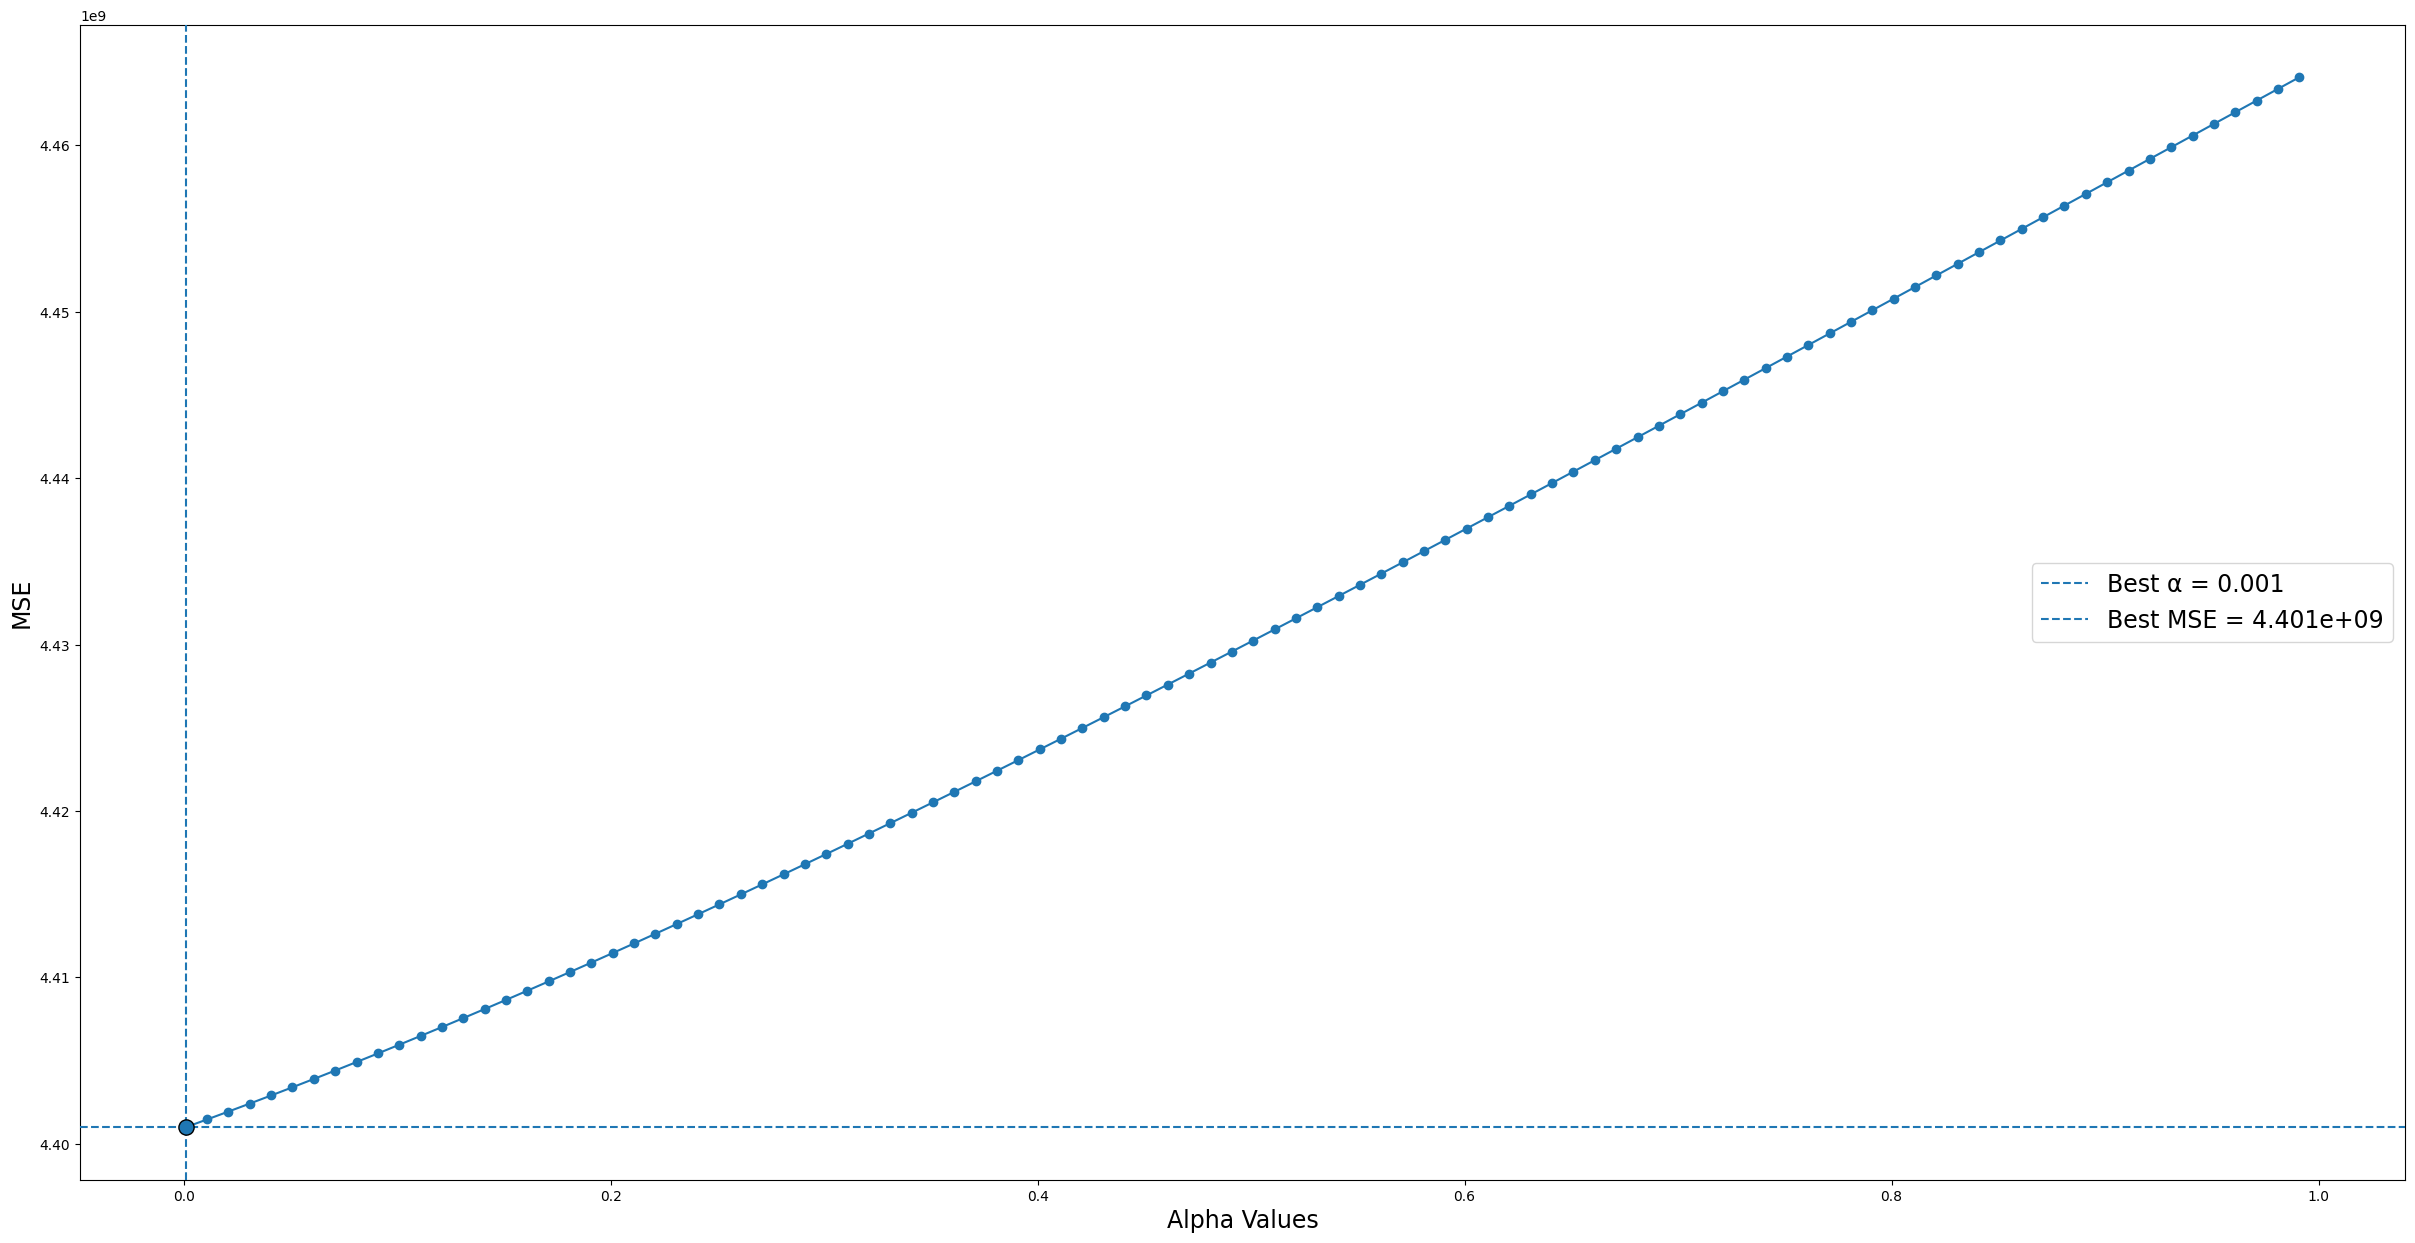

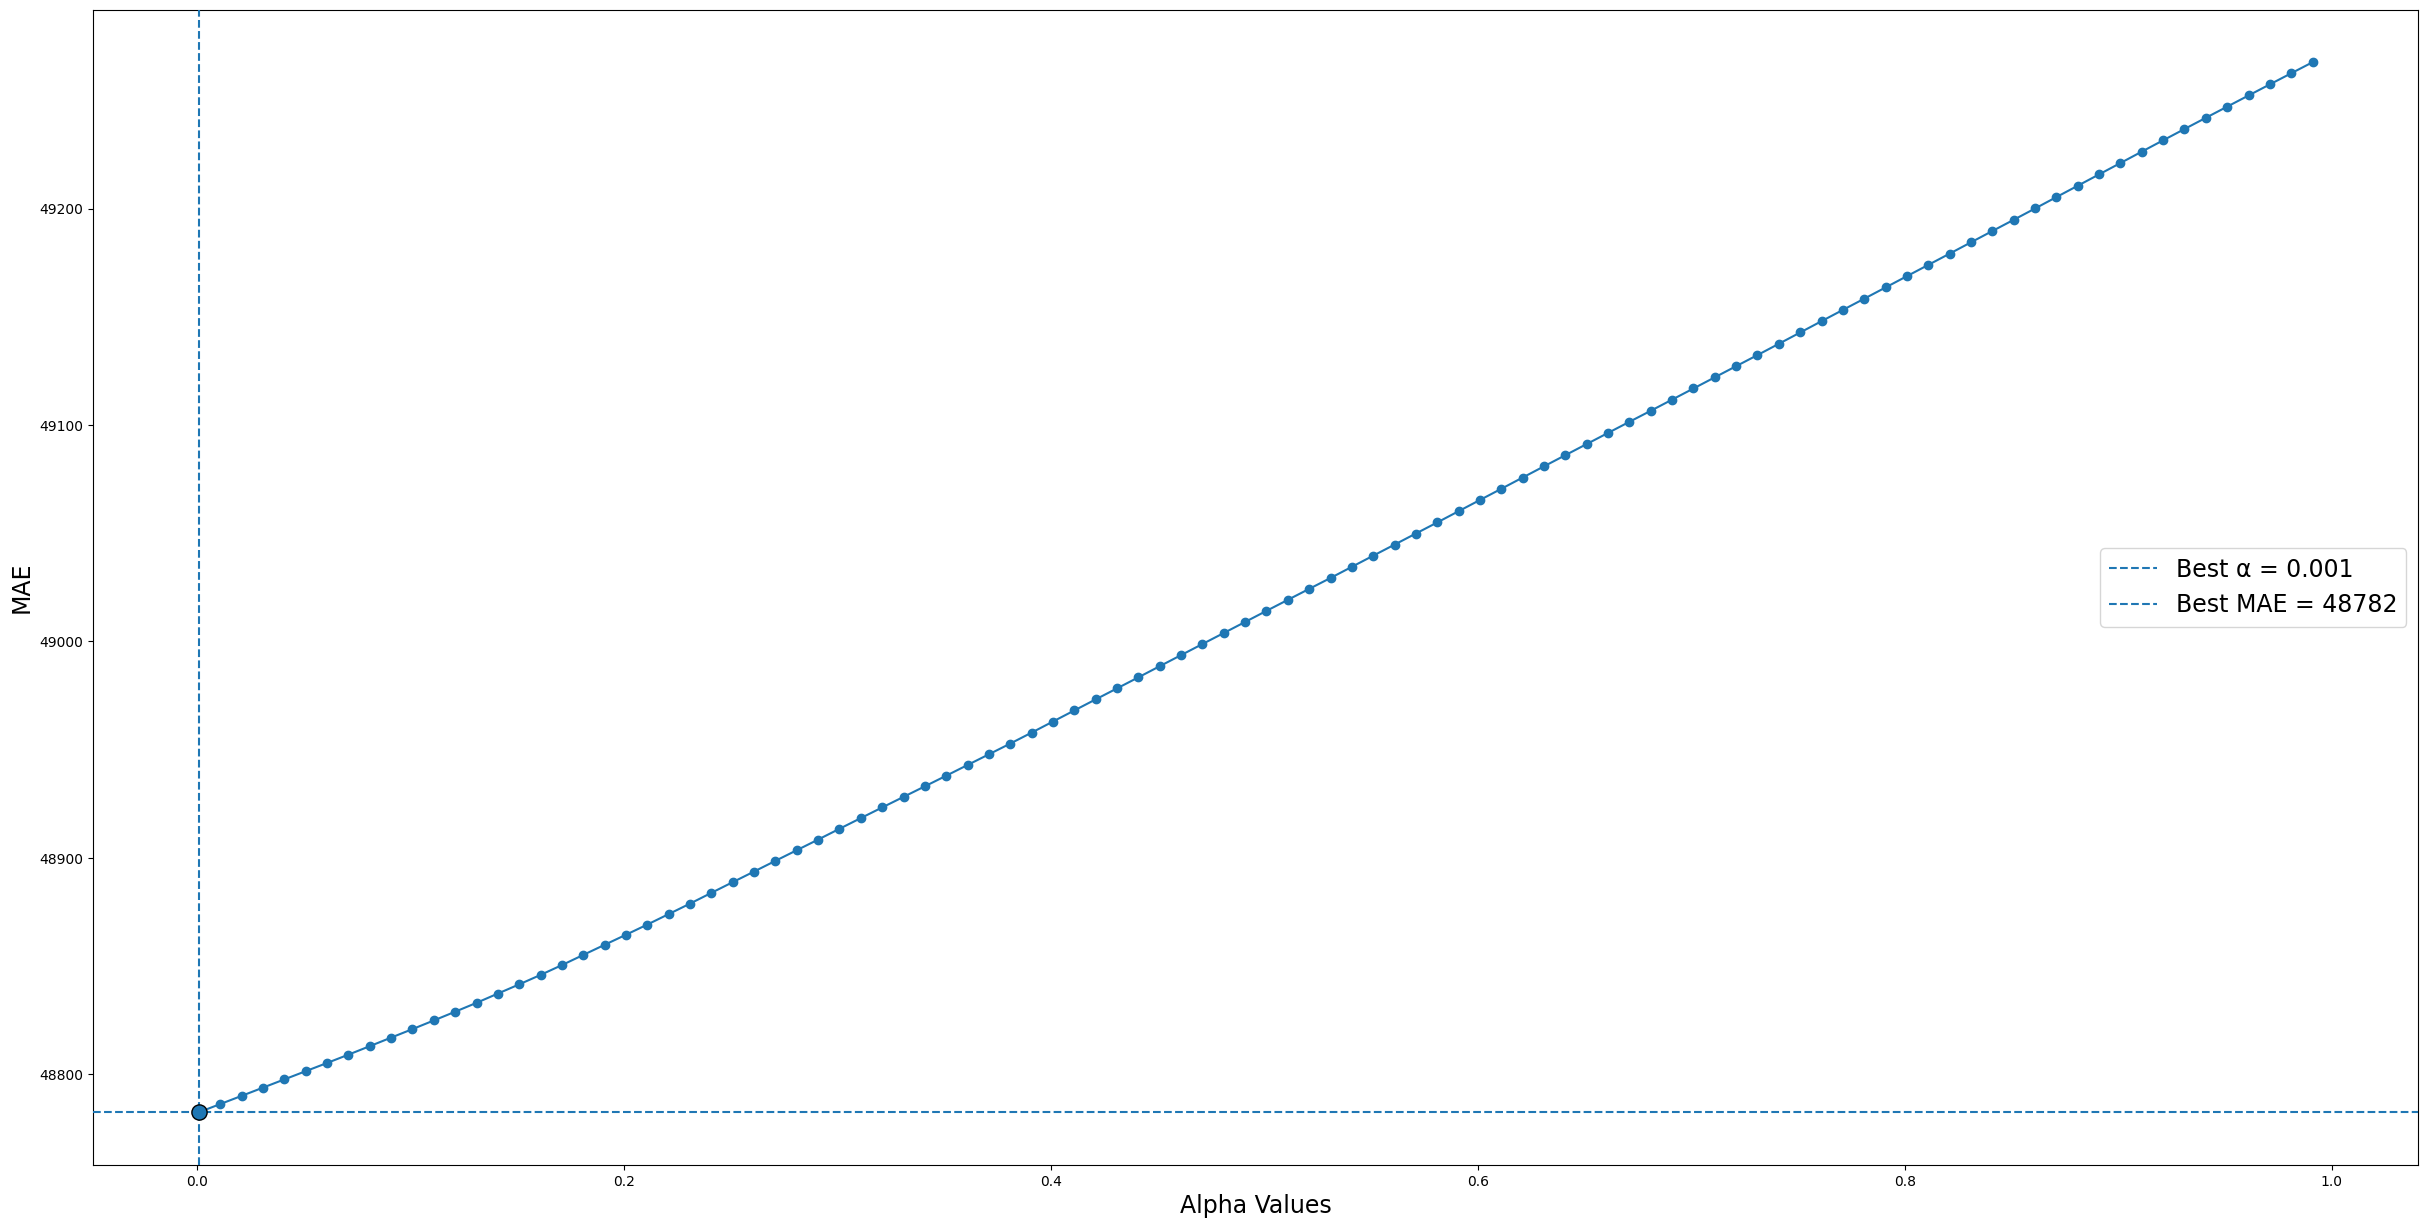

In [13]:
plot_accuracies(input_range, mse_val_list_ridge,"MSE",best_idx_mse)
plot_accuracies(input_range,  mae_val_list_ridge,"MAE",best_idx_mae)


### Getting MSE and MAE for test set

In [14]:
Ridge_model_mse = Ridge(alpha=best_alpha_mse)
Ridge_model_mse.fit(x_train, y_train)
y_pred_ridge_mse = Ridge_model.predict(x_test)
mse_val = mean_squared_error(y_test, y_pred_ridge_mse)

Ridge_model_mae = Ridge(alpha=best_alpha_mae)
Ridge_model_mae.fit(x_train, y_train)
y_pred_ridge_mae = Ridge_model.predict(x_test)
mae_val = mean_absolute_error(y_test, y_pred_ridge_mae)

print(mse_val)
print(mae_val)

4942883614.036621
51116.706248683164


## Ridge Regularization Direct Immplemented class

In [ ]:
class RidgeRegressionDirectManual:
    def __init__(self, alpha=1):
        self.alpha=alpha
        
    def fit(self,x_train,y_train):
        x=x_train
        # Adding bias term to the input features (a column of ones)
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        y=y_train
        numOfFeatures=x.shape[1]
        identity=np.eye(numOfFeatures)
        # Calculating weights using the Regularized Normal Equation: weights = (X^T * X + alphha * I)^(-1) * X^T * y
        firstTerm=np.linalg.inv(x.T @ x + self.alpha * identity) 
        secondTerm=x.T @ y
        self.weights=firstTerm @ secondTerm
        
    def predict_Direct(self,x_test):
        x=x_test
        # Adding bias term to the input features (a column of ones)
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        return x @ self.weights

### finding the best alpha for ridge direct

In [16]:
input_range = np.arange(.001,1,.01)
mse_val_list_ridge = []
mae_val_list_ridge = []

for i in input_range:
    Ridge_model = RidgeRegressionDirectManual(alpha=i)
    Ridge_model.fit(x_train, y_train)
    y_pred_ridge = Ridge_model.predict_Direct(x_val)
    
    mse_val = mean_squared_error(y_val, y_pred_ridge)
    mae_val = mean_absolute_error(y_val, y_pred_ridge)
    mse_val_list_ridge.append(mse_val)
    mae_val_list_ridge.append(mae_val)

    
best_idx_mse = int(np.argmin(mse_val_list_ridge))
best_alpha_mse = input_range[best_idx_mse]
best_idx_mae = int(np.argmin(mae_val_list_ridge))
best_alpha_mae = input_range[best_idx_mae]

print("Best alpha (by val MSE):", best_alpha_mse)
print("Val MSE:", mse_val_list_ridge[best_idx_mse])
print("Best alpha (by val MAE):", best_alpha_mae)
print("Val MAE:", mae_val_list_ridge[best_idx_mae])

Best alpha (by val MSE): 0.001
Val MSE: 4401000439.139123
Best alpha (by val MAE): 0.001
Val MAE: 48782.40408875865


### Ploting alpha vs errors

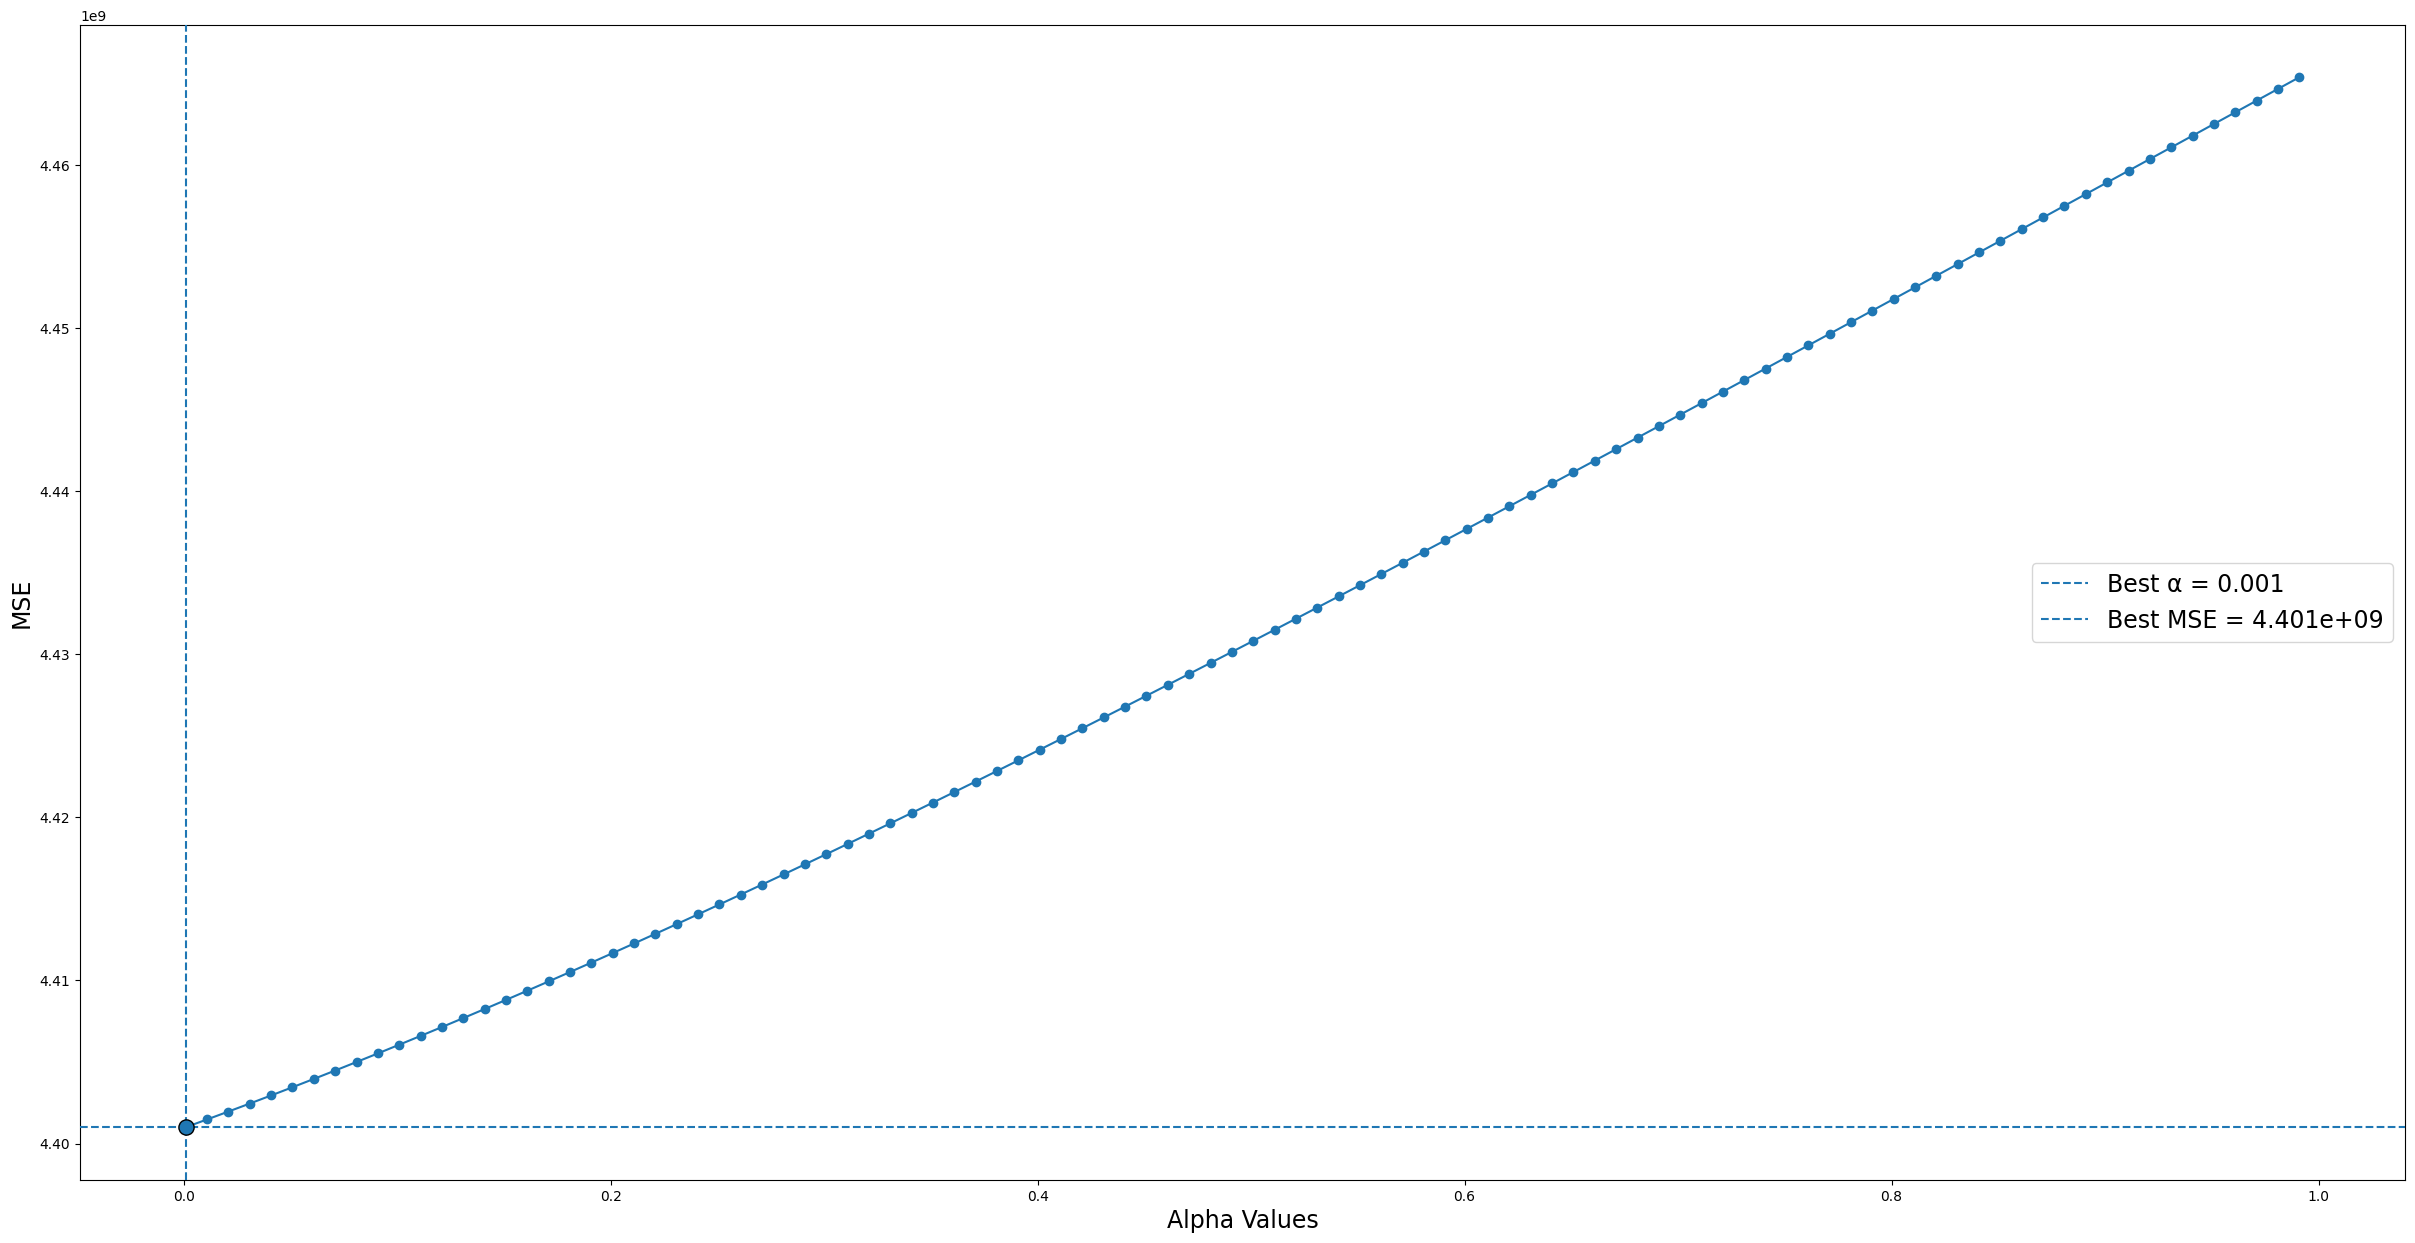

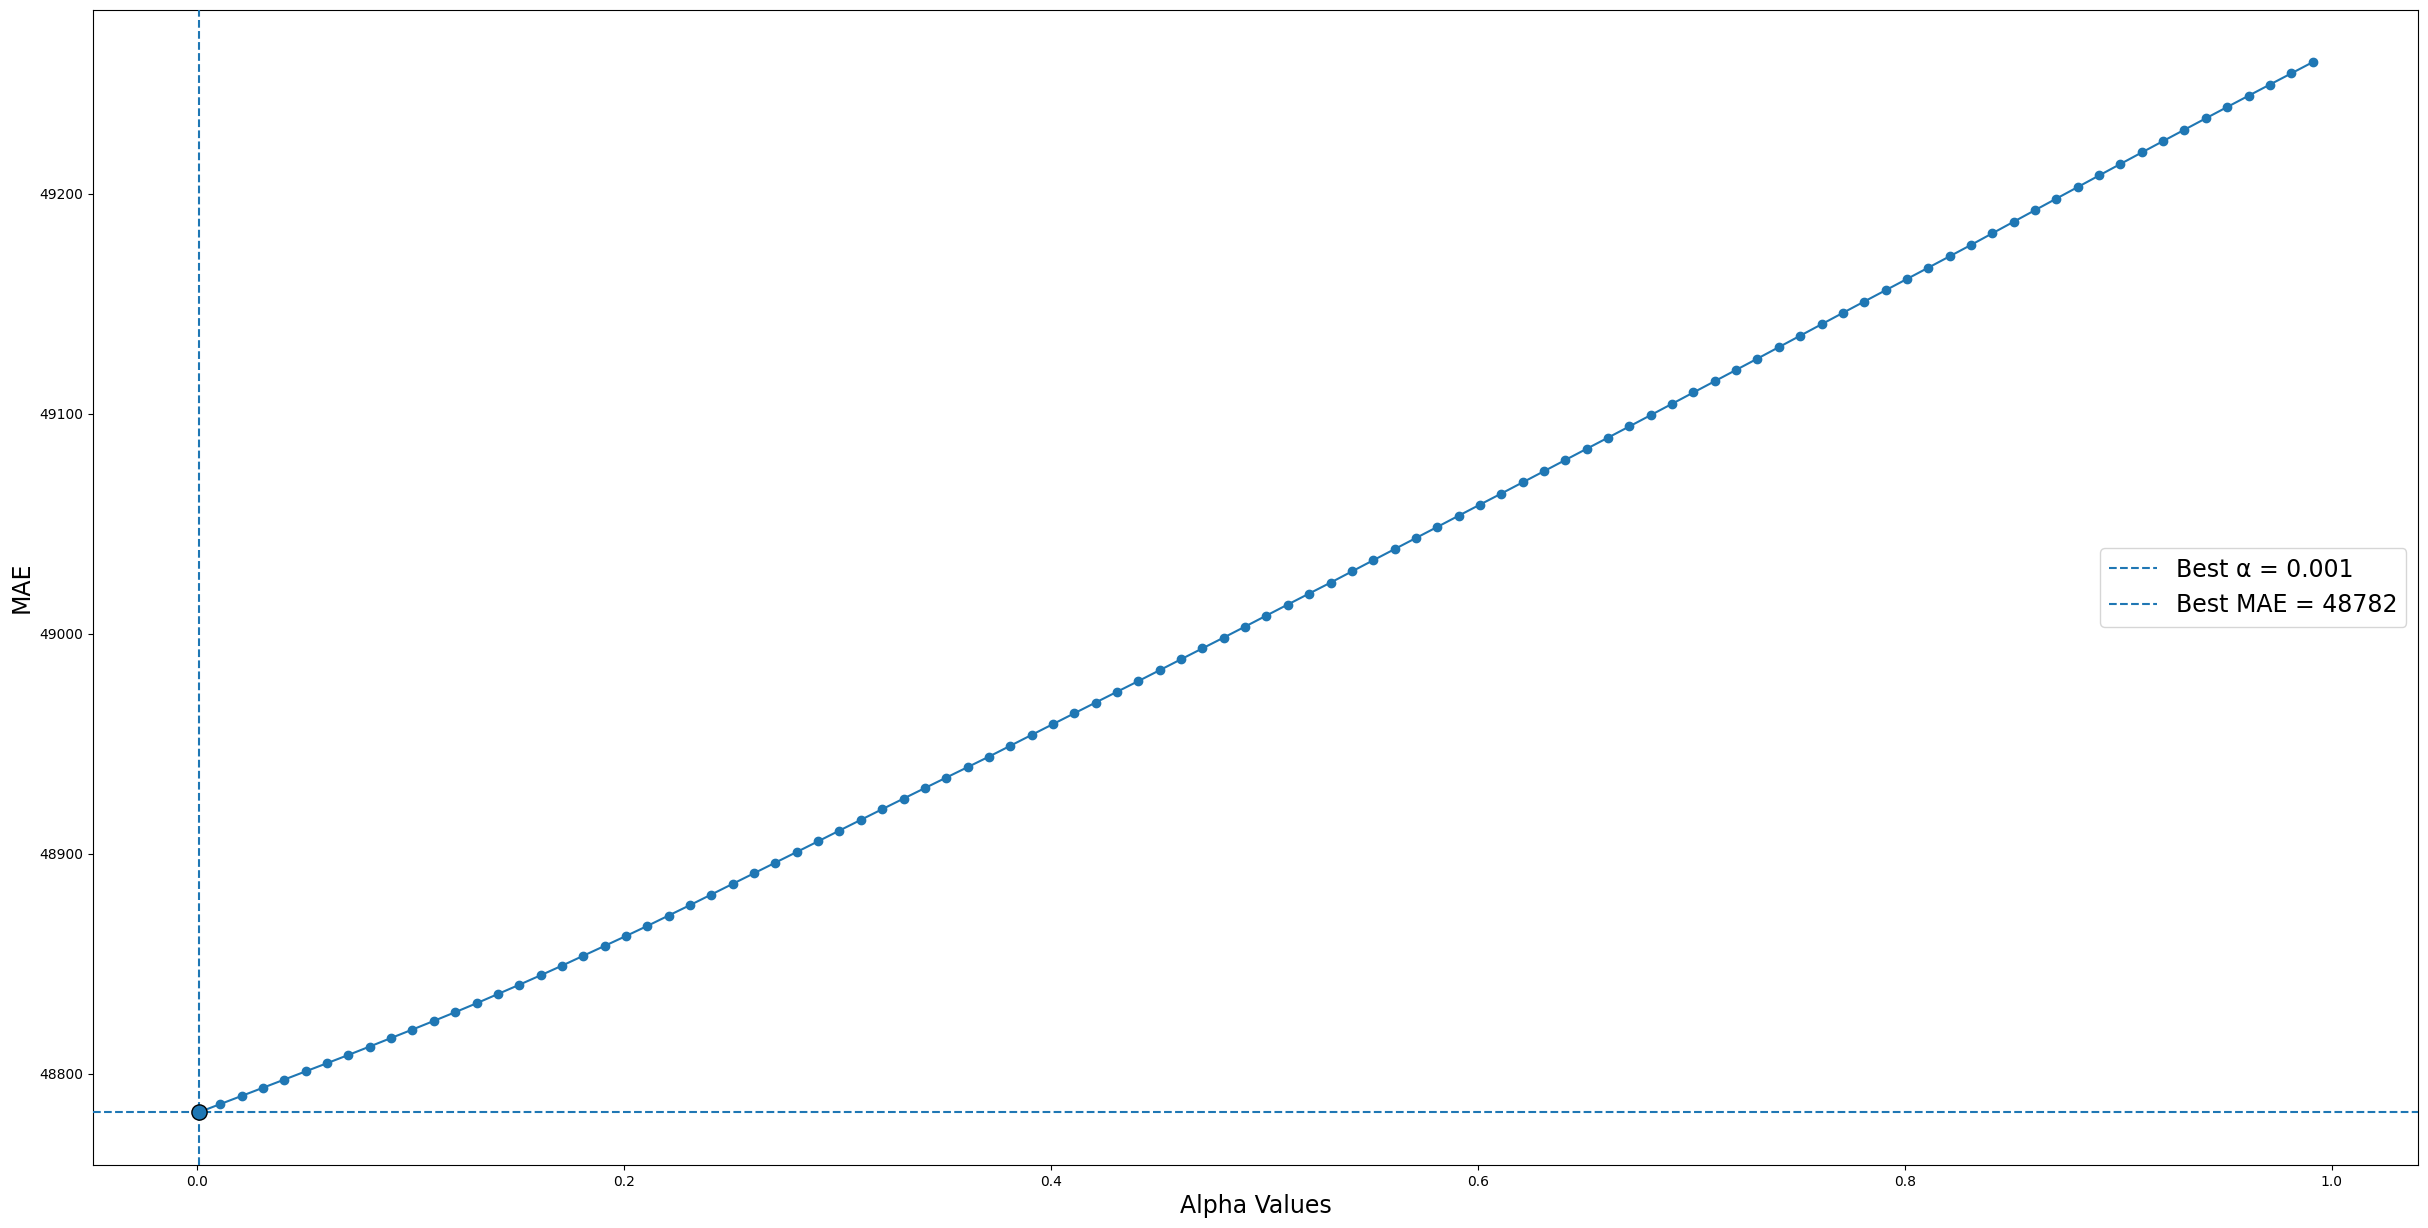

In [17]:
plot_accuracies(input_range, mse_val_list_ridge,"MSE",best_idx_mse)
plot_accuracies(input_range,  mae_val_list_ridge,"MAE",best_idx_mae)

### Getting MSE and MAE for test set using Ridge Direct

In [18]:
Ridge_model_mse = RidgeRegressionDirectManual(alpha=best_alpha_mse)
Ridge_model_mse.fit(x_train, y_train)
y_pred_ridge_mse = Ridge_model.predict_Direct(x_test)
mse_val = mean_squared_error(y_test, y_pred_ridge_mse)

Ridge_model_mae = Ridge(alpha=best_alpha_mae)
Ridge_model_mae.fit(x_train, y_train)
y_pred_ridge_mae = Ridge_model.predict_Direct(x_test)
mae_val = mean_absolute_error(y_test, y_pred_ridge_mae)

print(mse_val)
print(mae_val)

4944142166.204896
51115.961147488495


## Ridge Regularization Gradient Descent Implemented class

In [ ]:
class RidgeRegressionGradientManual:
    def __init__(self,alpha=1,learning_step=.01,numOfIterations=100000,tolerance=1e-6):
        self.learning_step=learning_step
        self.numOfIterations=numOfIterations
        self.alpha=alpha
        self.tolerance=tolerance
        
    def fit(self,x_train,y_train):
        x=x_train
        y=y_train
        numOfFeatures=x.shape[1]
        numOfSamples=x.shape[0]
        #adding bias term to the input features (a column of ones)
        ones=np.ones((numOfSamples,1))
        x=np.hstack([ones,x])
        #setting random seed to get the same results every run
        np.random.seed(42)
        
        identity=np.eye(numOfFeatures+1)
        #initialize random weights
        self.weights=np.random.randn(numOfFeatures+1)
        prev_cost=float('inf')
        for i in range (self.numOfIterations):
            y_pred= x @ self.weights
            error=y_pred - y
            #compute gradient with regularization
            grad = (2.0 / numOfSamples) * (x.T @ error)  
            reg_grad = 2.0 * self.alpha * self.weights
            reg_grad[0] = 0.0                          
            grad += reg_grad

            self.weights-=self.learning_step * grad
            current_cost=self._calculateCost(x,y,self.weights)
            if(abs(current_cost-prev_cost)<self.tolerance):
                    break
            prev_cost=current_cost       
            
    def _calculateCost(self, x, y, weights):
        y_pred = x @ weights
        cost = np.mean((y_pred - y) ** 2)
        return cost     
    
    def predict_Gradient(self,x_test):
    
        x=x_test
        ones=np.ones((x.shape[0],1))
        x=np.hstack([ones,x])
        return x @ self.weights

### finding best alpha for rigid using gradient 

In [20]:
input_range = [.0001,.001,.01,.1,1]
mse_val_list_ridge = []
mae_val_list_ridge = []

for i in input_range:
    Ridge_model = RidgeRegressionGradientManual(alpha=i)
    Ridge_model.fit(x_train, y_train)
    y_pred_ridge = Ridge_model.predict_Gradient(x_val)
    
    mse_val = mean_squared_error(y_val, y_pred_ridge)
    mae_val = mean_absolute_error(y_val, y_pred_ridge)
    mse_val_list_ridge.append(mse_val)
    mae_val_list_ridge.append(mae_val)

    
best_idx_mse = int(np.argmin(mse_val_list_ridge))
best_alpha_mse = input_range[best_idx_mse]
best_idx_mae = int(np.argmin(mae_val_list_ridge))
best_alpha_mae = input_range[best_idx_mae]

print("Best alpha (by val MSE):", best_alpha_mse)
print("Val MSE:", mse_val_list_ridge[best_idx_mse])
print("Best alpha (by val MAE):", best_alpha_mae)
print("Val MAE:", mae_val_list_ridge[best_idx_mae])

Best alpha (by val MSE): 0.0001
Val MSE: 4726125433.870895
Best alpha (by val MAE): 0.0001
Val MAE: 50992.30727515724


### Ploting alpha vs errors

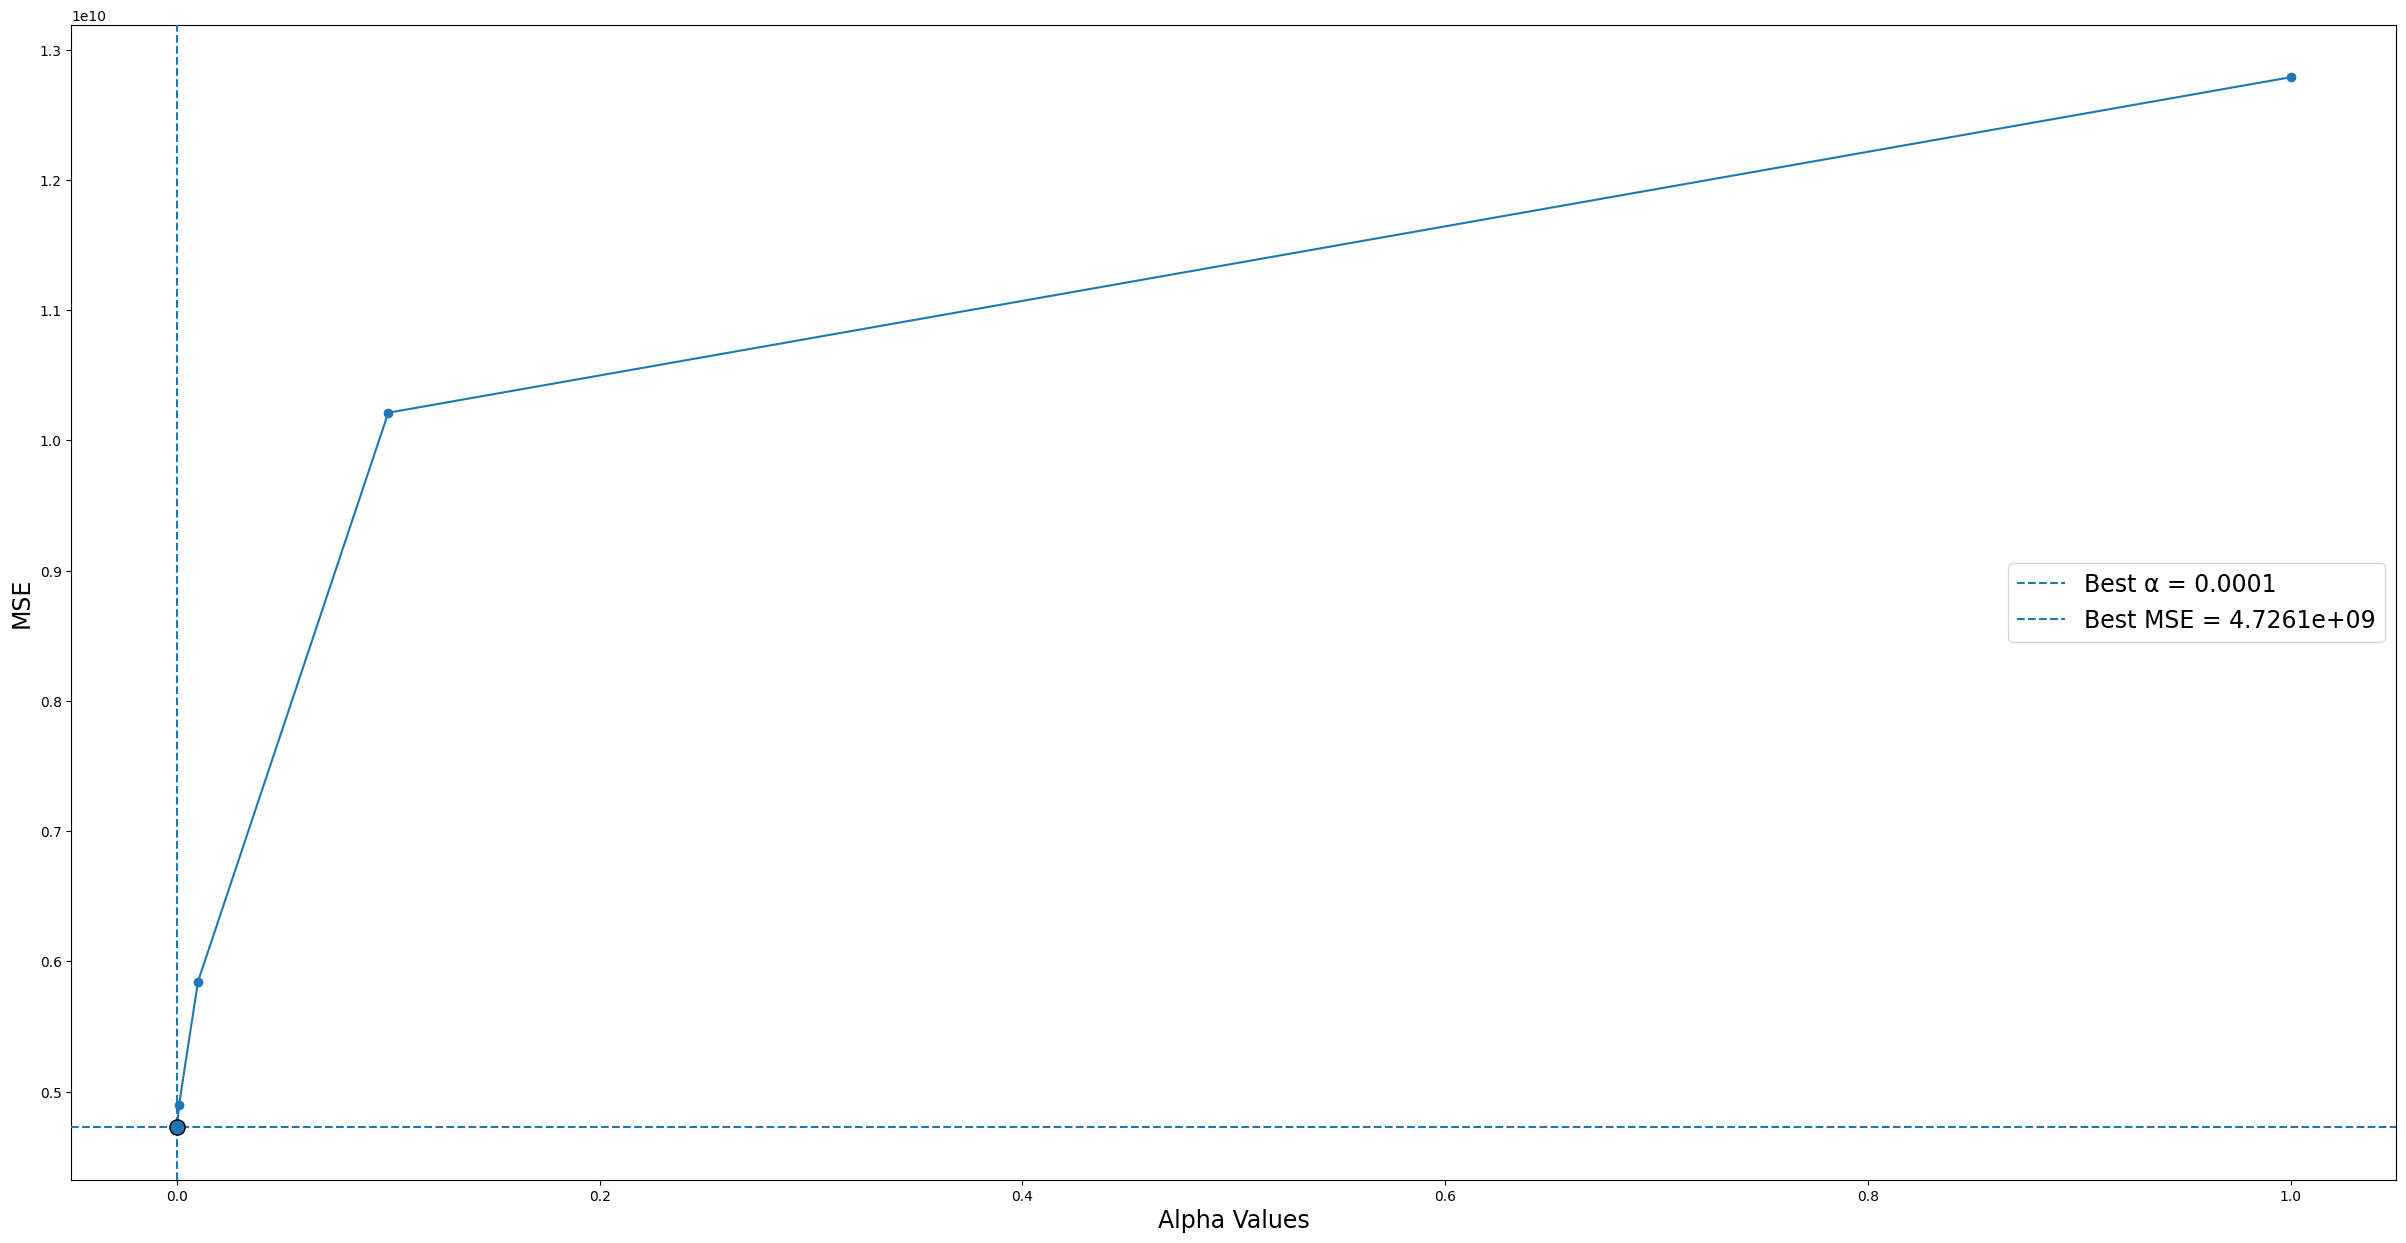

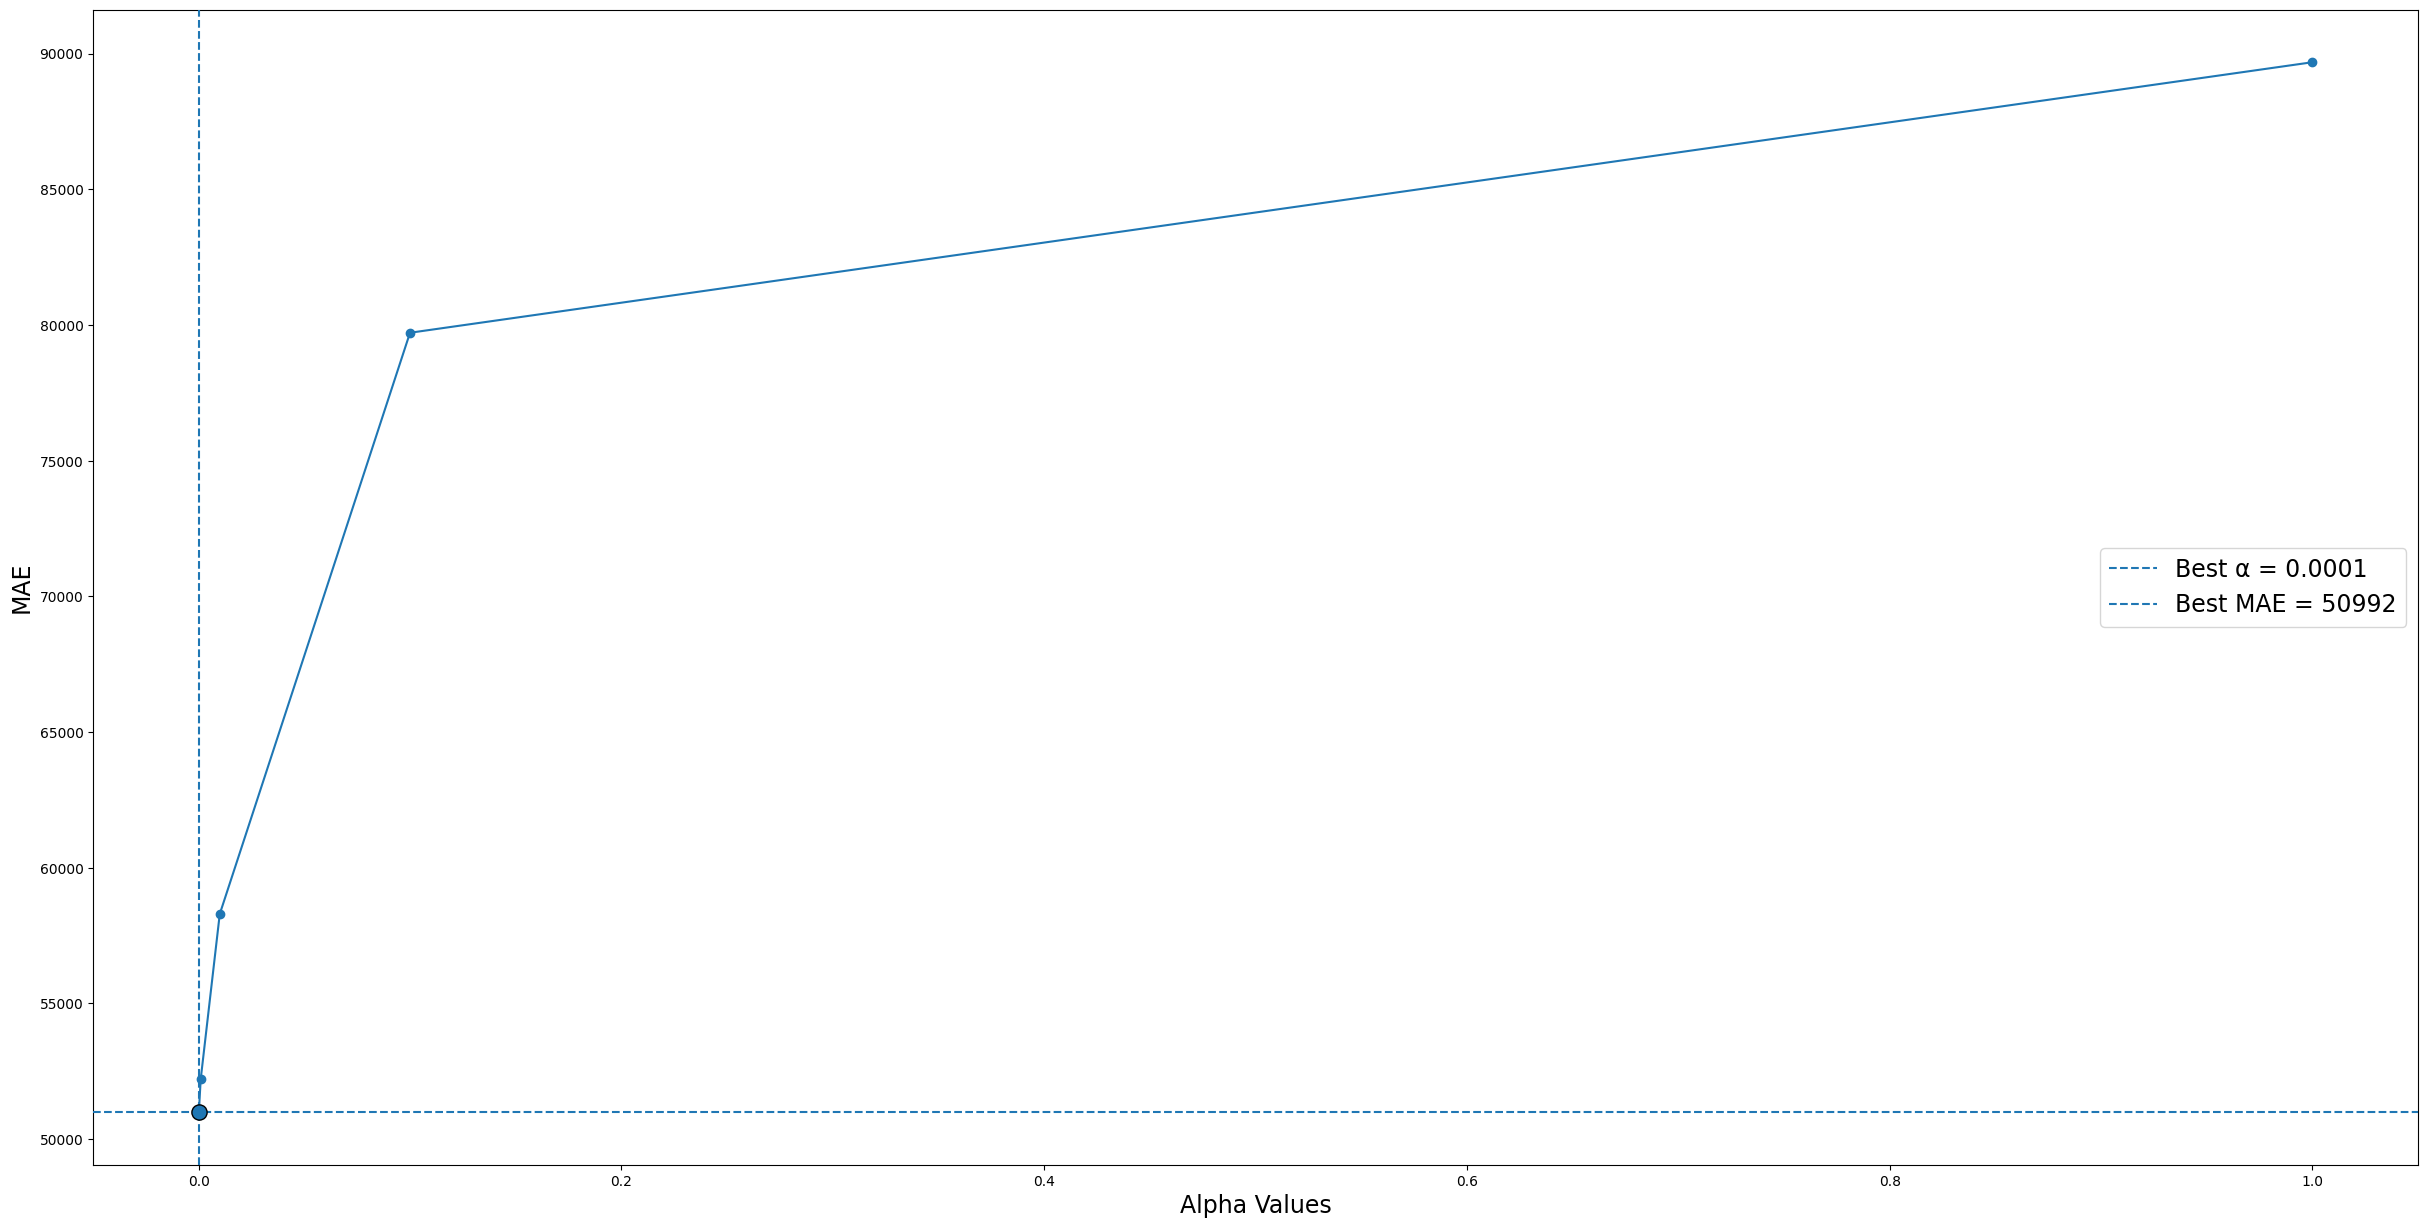

In [21]:
plot_accuracies(input_range, mse_val_list_ridge,"MSE",best_idx_mse)
plot_accuracies(input_range,  mae_val_list_ridge,"MAE",best_idx_mae)

### Getting MSE and MAE for test set using Ridge Gradient

In [22]:

Ridge_model_mse = RidgeRegressionGradientManual(alpha=best_alpha_mse)
Ridge_model_mse.fit(x_train, y_train)
y_pred_ridge_mse = Ridge_model_mse.predict_Gradient(x_val)
mse_val = mean_squared_error(y_val, y_pred_ridge_mse)

Ridge_model_mae = RidgeRegressionGradientManual(alpha=best_alpha_mae)
Ridge_model_mae.fit(x_train, y_train)
y_pred_ridge_mae = Ridge_model_mae.predict_Gradient(x_val)
mae_val = mean_absolute_error(y_val, y_pred_ridge_mae)

print(mse_val)
print(mae_val)

4726125433.870895
50992.30727515724


## Lasso Regularization from sklearn

In [ ]:

mse_train_list_lasso = []
mse_val_list_lasso = []
mae_train_list_lasso = []
mae_val_list_lasso = []
for i in input_range:
    Lasso_model = Lasso(alpha=i,max_iter=100000)
    Lasso_model.fit(x_train, y_train)
    y_pred_lasso = Lasso_model.predict(x_val)
    y_pred_lasso_train = Lasso_model.predict(x_train)
    
    mse_val = mean_squared_error(y_val, y_pred_lasso)
    mae_val = mean_absolute_error(y_val, y_pred_lasso)
    
    mse_val_list_lasso.append(mse_val)
    mae_val_list_lasso.append(mae_val)
    
best_idx_mse = int(np.argmin(mse_val_list_lasso))
best_alpha_mse = input_range[best_idx_mse]
best_idx_mae = int(np.argmin(mae_val_list_lasso))
best_alpha_mae = input_range[best_idx_mae]

print("Best alpha (by val MSE):", best_alpha_mse)
print("Val MSE:", mse_val_list_ridge[best_idx_mse])
print("Best alpha (by val MAE):", best_alpha_mae)
print("Val MAE:", mae_val_list_ridge[best_idx_mae])

Best alpha (by val MSE): 0.0001
Val MSE: 4726125433.870895
Best alpha (by val MAE): 0.0001
Val MAE: 50992.30727515724


### ploting alpha vs errors

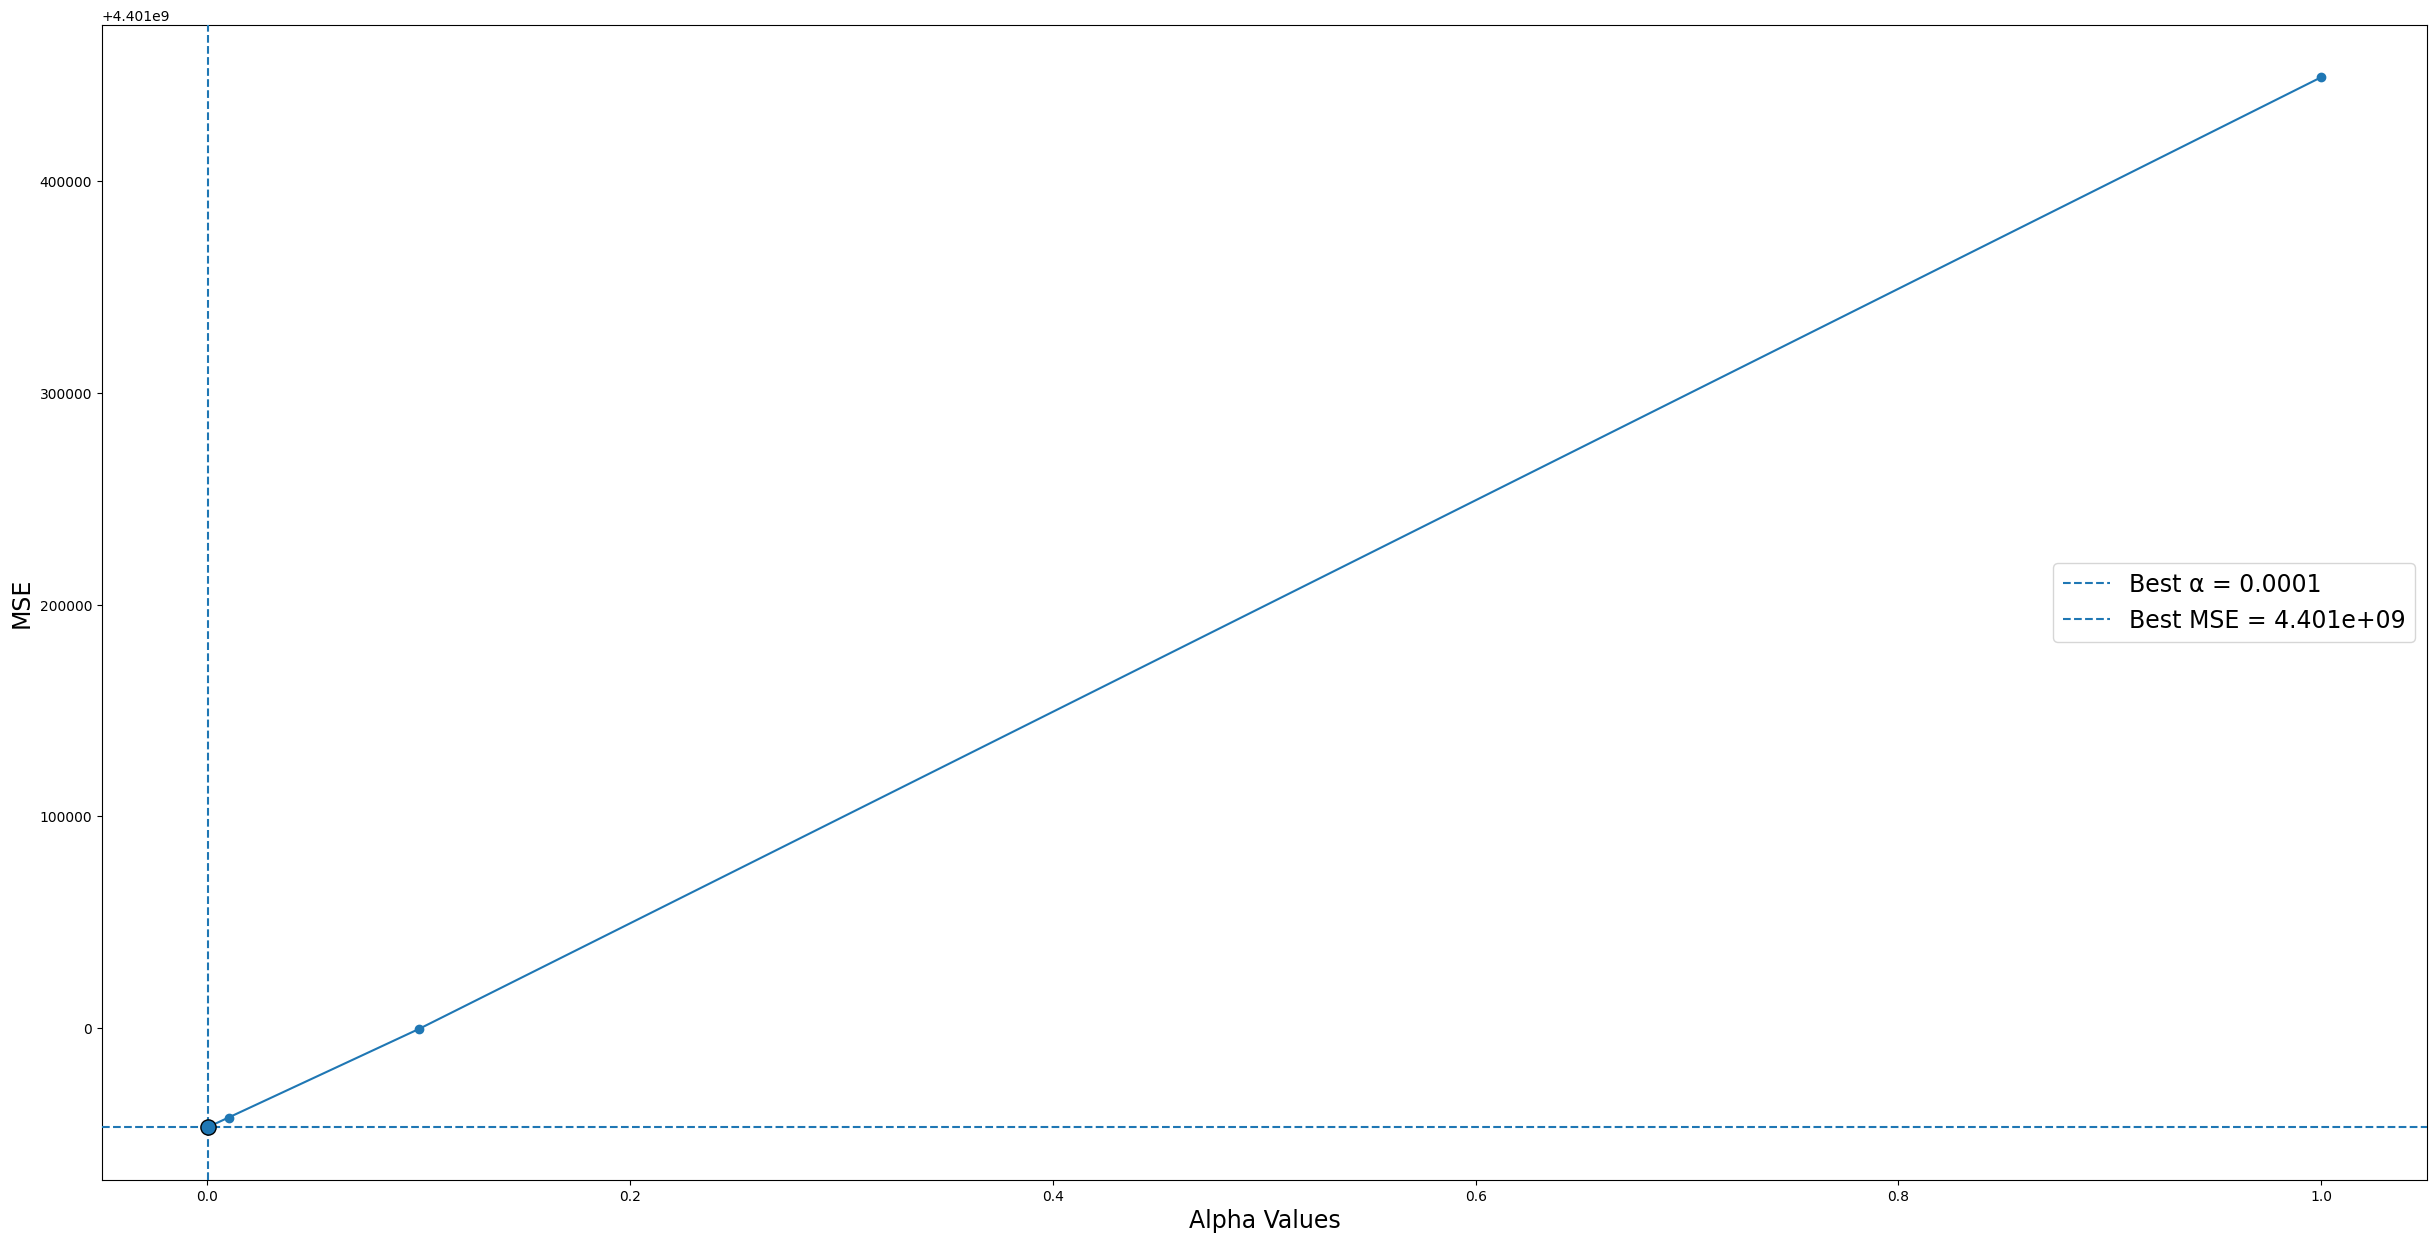

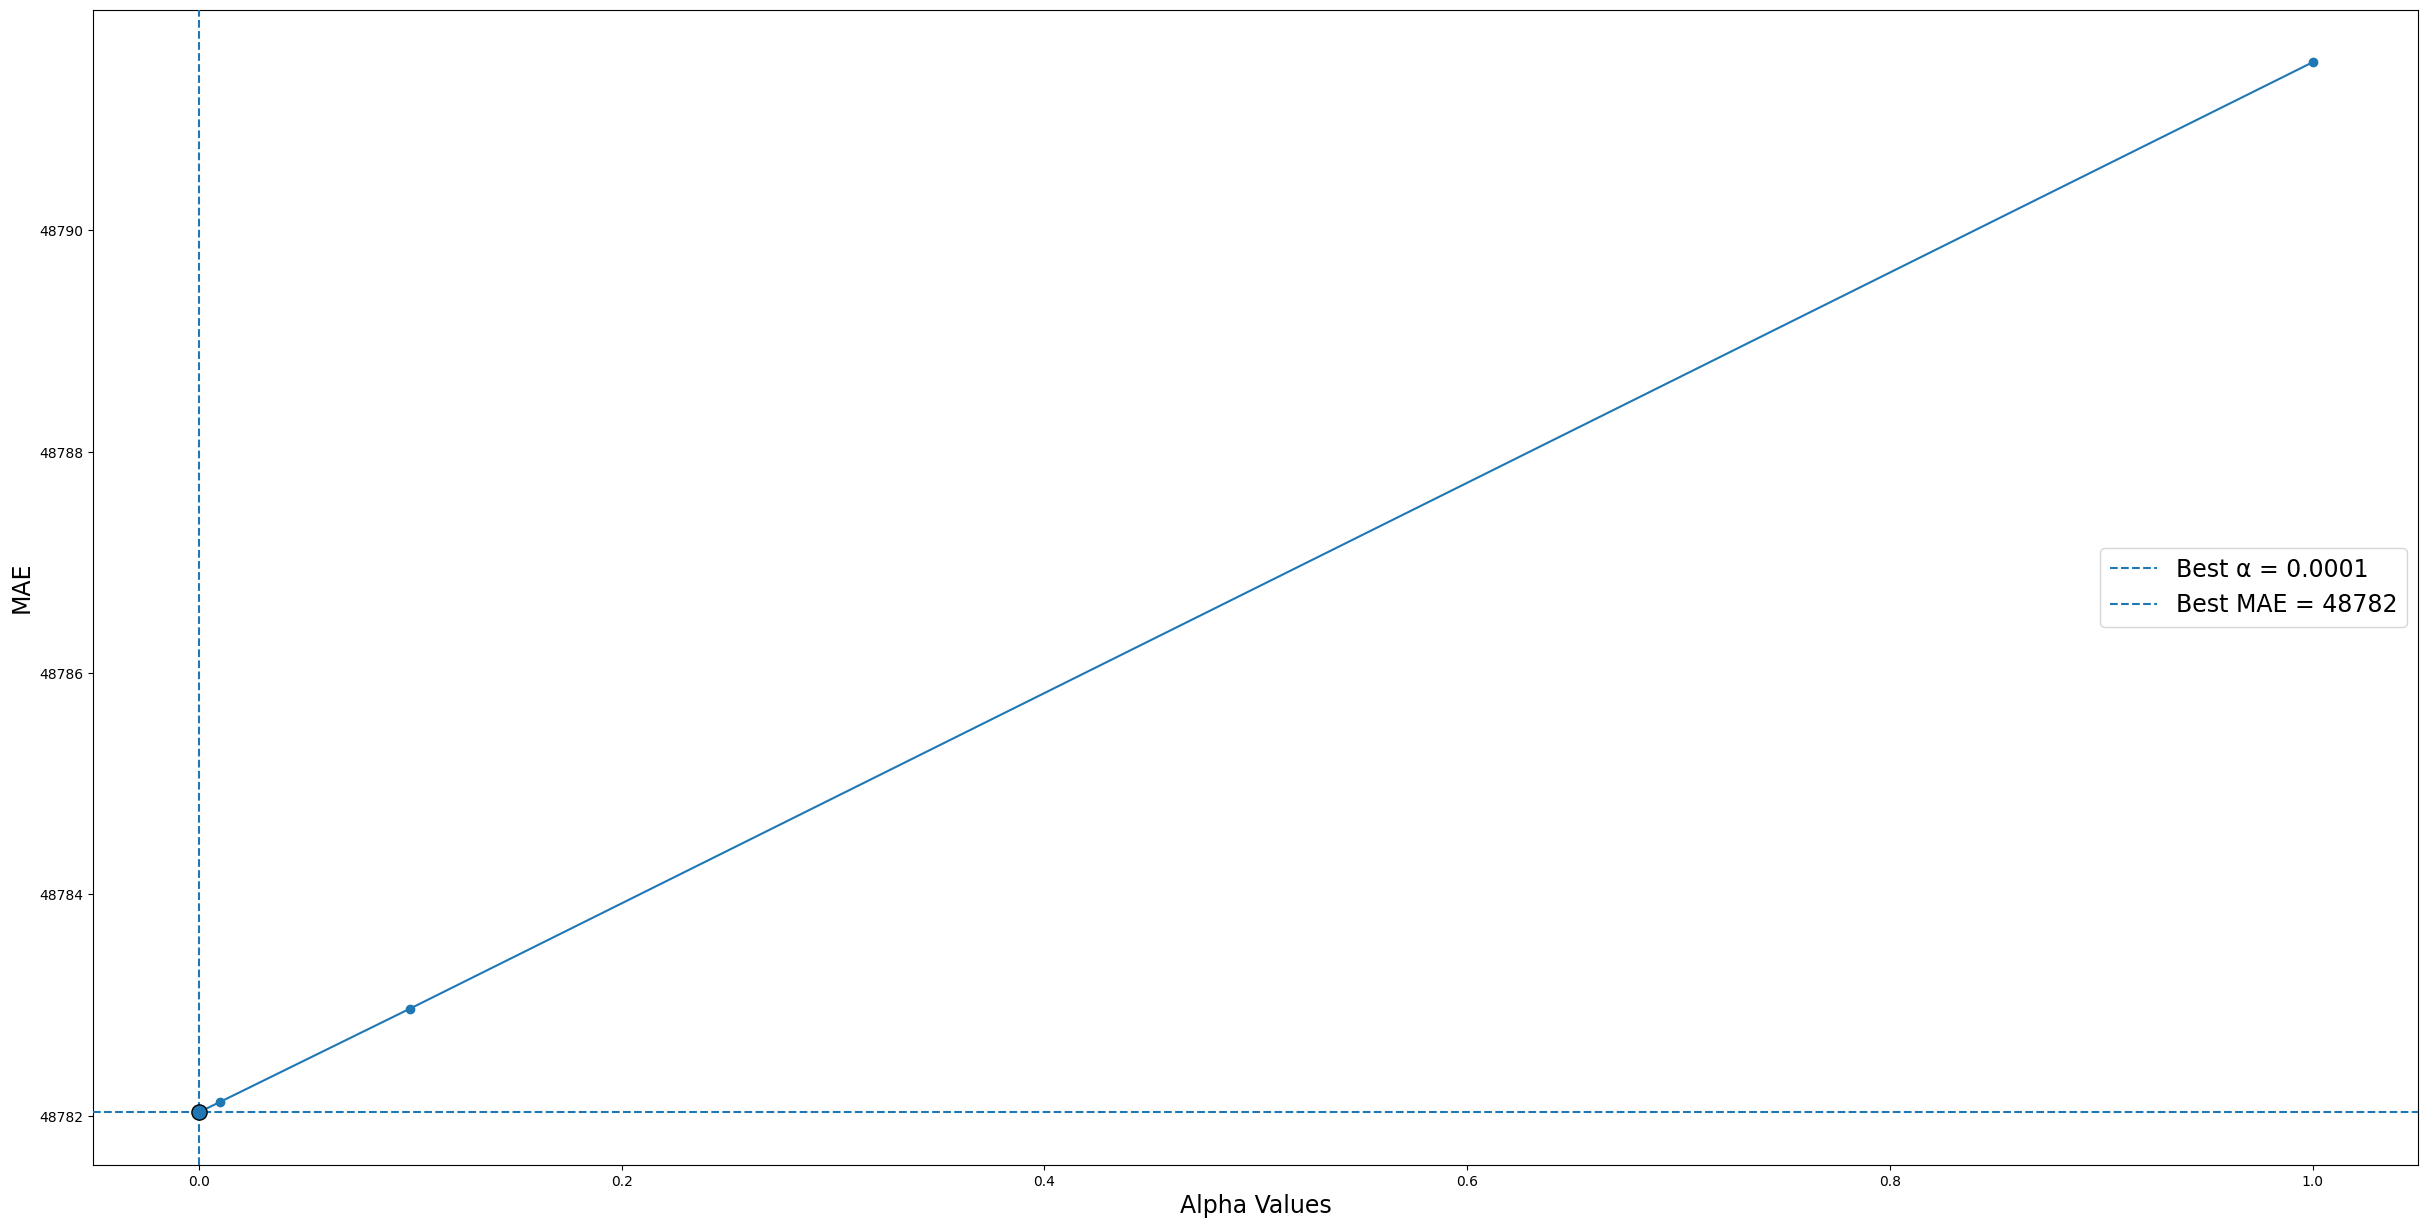

In [24]:

plot_accuracies(input_range,  mse_val_list_lasso,"MSE",best_idx_mse)
plot_accuracies(input_range,  mae_val_list_lasso,"MAE",best_idx_mae)

### Getting MSE and MAE for test set using lasso

In [25]:
lasso_model_mse = Lasso(alpha=best_alpha_mse,max_iter=100000)
lasso_model_mse.fit(x_train, y_train)
y_pred_lasso_mse = lasso_model_mse.predict(x_test)
mse_val = mean_squared_error(y_test, y_pred_lasso_mse)

lasso_model_mae = Lasso(alpha=best_alpha_mae,max_iter=100000)
lasso_model_mae.fit(x_train, y_train)
y_pred_lasso_mae = lasso_model_mae.predict(x_test)
mae_val = mean_absolute_error(y_test, y_pred_lasso_mae)

print(mse_val)
print(mae_val)

4907212007.641696
50790.06096379534
